[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Two story 3D Frame vibration

Last updated: 07/12/26

## Problem description

Three-dimensional two story frame vibration. The frame members are automatically
refined into multiple elements.

The comparison is made four four modes of vibration. The mode shapes correlate
reasonably well. The agreement of the frequencies is decent, but there are small
discrepancies, which we can explore interactively.

## References

Example 5.3 from the book: MECHANICAL VIBRATIONS THEORY AND APPLICATION TO
STRUCTURAL DYNAMICS, ThirdEdition, Michel Géradin, Daniel J. Rixen

Original citation: Samcef. 1992 Samcef manual: Asef–Stabi–Dynam–Repdyn (M4)
Samtech SA Liège, Belgium.

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [119]:
import context
from pystran import model
from pystran import section
from pystran import plots

The material is steel, SI units (m).


In [120]:
E = 2.1e11
G = E / (2 * (1 + 0.3))
rho = 7.8e3

The cross section properties are given in SI units (m).

Columns.


In [121]:
A = 5.14e-3
Iy = 6.9e-6
Iz = 8.49e-5
Ix = Iy + Iz
J = 1.73e-7
xz_vector = [0, 1, 0]
sverti = section.beam_3d_section(
    "sverti", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Horizontal beams.


In [122]:
A = 5.68e-3
Iy = 1.2e-4
Iz = 7.3e-6
Ix = Iy + Iz
J = 1.76e-7
xz_vector = [0, 0, 1]
shoriz = section.beam_3d_section(
    "shoriz", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Grid spacing and height of the floors.


In [123]:
a = 5.49
b = 3.66

In [124]:
m = model.create(3)
freedoms = m["freedoms"]

Bottoms of columns.


In [125]:
model.add_joint(m, 1, [0.0, 0.0, 0.0])
model.add_joint(m, 2, [a, 0.0, 0.0])
model.add_joint(m, 3, [a, a, 0.0])
model.add_joint(m, 4, [0.0, a, 0.0])

{'jid': 4, 'coordinates': array([0.  , 5.49, 0.  ])}

First floor.


In [126]:
model.add_joint(m, 11, [0.0, 0.0, b])
model.add_joint(m, 12, [a, 0.0, b])
model.add_joint(m, 13, [a, a, b])
model.add_joint(m, 14, [0.0, a, b])

{'jid': 14, 'coordinates': array([0.  , 5.49, 3.66])}

Second floor.


In [127]:
model.add_joint(m, 21, [0.0, 0.0, 2 * b])
model.add_joint(m, 22, [a, 0.0, 2 * b])
model.add_joint(m, 23, [a, a, 2 * b])
model.add_joint(m, 24, [0.0, a, 2 * b])

{'jid': 24, 'coordinates': array([0.  , 5.49, 7.32])}

Fix the bottoms of the columns.


In [128]:
for jid in range(1, 5):
    model.add_support(m["joints"][jid], freedoms.ALL_DOFS)

Add the members.


In [129]:
model.add_beam_member(m, 1, [1, 11], sverti)
model.add_beam_member(m, 2, [2, 12], sverti)
model.add_beam_member(m, 3, [3, 13], sverti)
model.add_beam_member(m, 4, [4, 14], sverti)

{'mid': 4,
 'connectivity': [4, 14],
 'section': {'name': 'sverti',
  'E': 210000000000.0,
  'G': 80769230769.23077,
  'rho': 7800.0,
  'CTE': 0.0,
  'A': 0.00514,
  'Ix': 9.180000000000001e-05,
  'Iy': 6.9e-06,
  'Iz': 8.49e-05,
  'J': 1.73e-07,
  'xy_vector': None,
  'xz_vector': array([0, 1, 0])}}

In [130]:
model.add_beam_member(m, 5, [11, 21], sverti)
model.add_beam_member(m, 6, [12, 22], sverti)
model.add_beam_member(m, 7, [13, 23], sverti)
model.add_beam_member(m, 8, [14, 24], sverti)

{'mid': 8,
 'connectivity': [14, 24],
 'section': {'name': 'sverti',
  'E': 210000000000.0,
  'G': 80769230769.23077,
  'rho': 7800.0,
  'CTE': 0.0,
  'A': 0.00514,
  'Ix': 9.180000000000001e-05,
  'Iy': 6.9e-06,
  'Iz': 8.49e-05,
  'J': 1.73e-07,
  'xy_vector': None,
  'xz_vector': array([0, 1, 0])}}

In [131]:
model.add_beam_member(m, 9, [11, 12], shoriz)
model.add_beam_member(m, 10, [12, 13], shoriz)
model.add_beam_member(m, 11, [13, 14], shoriz)
model.add_beam_member(m, 12, [14, 11], shoriz)

{'mid': 12,
 'connectivity': [14, 11],
 'section': {'name': 'shoriz',
  'E': 210000000000.0,
  'G': 80769230769.23077,
  'rho': 7800.0,
  'CTE': 0.0,
  'A': 0.00568,
  'Ix': 0.0001273,
  'Iy': 0.00012,
  'Iz': 7.3e-06,
  'J': 1.76e-07,
  'xy_vector': None,
  'xz_vector': array([0, 0, 1])}}

In [132]:
model.add_beam_member(m, 13, [21, 22], shoriz)
model.add_beam_member(m, 14, [22, 23], shoriz)
model.add_beam_member(m, 15, [23, 24], shoriz)
model.add_beam_member(m, 16, [24, 21], shoriz)

{'mid': 16,
 'connectivity': [24, 21],
 'section': {'name': 'shoriz',
  'E': 210000000000.0,
  'G': 80769230769.23077,
  'rho': 7800.0,
  'CTE': 0.0,
  'A': 0.00568,
  'Ix': 0.0001273,
  'Iy': 0.00012,
  'Iz': 7.3e-06,
  'J': 1.76e-07,
  'xy_vector': None,
  'xz_vector': array([0, 0, 1])}}

Optionally we can refine the members into multiple finite elements. In the
book, there is indication that the results are for a single element per member. The
accuracy of the frequencies will be driven by the number of elements, since a
single element cannot represent the deflections in the interior of the
members. We will use three elements per member:


In [133]:
nref = 3
for i in range(16):
    model.refine_member(m, i + 1, nref)


If you wish to see the results for a single element per member, comment out
those three lines above.

Solve the problem. 
First number all the degrees of freedom:

In [134]:
model.number_dofs(m)


The number of free degrees of freedom is


In [135]:
print(f"Number of degrees of freedom: {m['nfreedof']}")
model.solve_free_vibration(m)

Number of degrees of freedom: 240


The textbook cites the following frequencies (for a single finite element
per member):


In [136]:
reffs = [3.08, 4.65, 7.87, 8.23]


Our results will be slightly lower, is because we use multiple elements per
member.

Plot the modes and compare the frequencies. The mode shapes correlate with
those published in the reference.


Note: we use multiple elements per member. Our frequencies will be lower.
Mode 0: 3.067 Hz
  Reference:  3.08


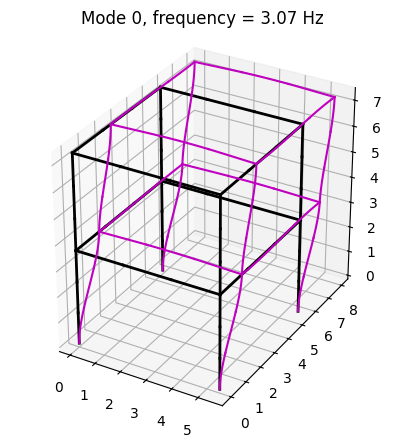

Mode 1: 4.648 Hz
  Reference:  4.65


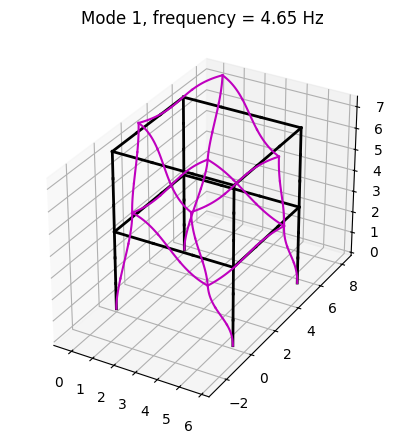

Mode 2: 7.694 Hz
  Reference:  7.87


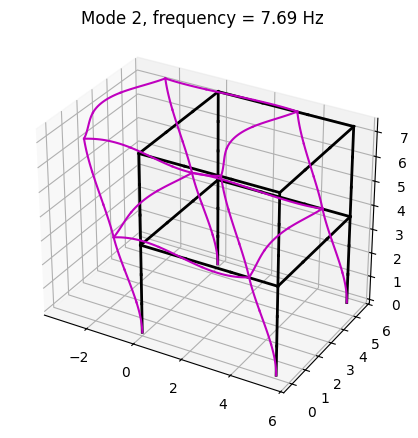

Mode 3: 8.019 Hz
  Reference:  8.23


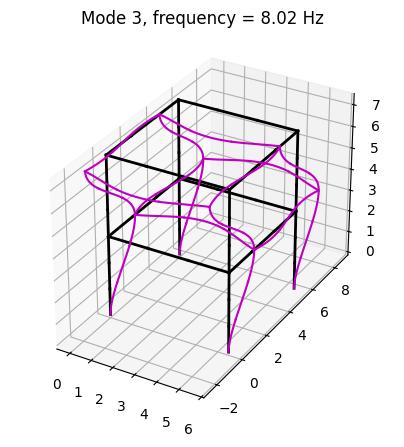

In [137]:
print("Note: we use multiple elements per member. Our frequencies will be lower.")
for mode in range(0, 4):
    print(f"Mode {mode}: {m['frequencies'][mode]:.3f} Hz")
    print("  Reference: ", reffs[mode])
    ax = plots.setup(m)
    plots.plot_members(m)
    model.set_solution(m, m["eigvecs"][:, mode])
    plots.plot_deformations(m, 100.0)
    ax.set_title(f"Mode {mode}, frequency = {m['frequencies'][mode]:.2f} Hz")
    plots.show(m)

## Conclusions

The free vibration of a 3D frame is solved and compared with an analytical solution. The agreement is good but not perfect. However, the number of elements in our solution is higher than that in the reference. If we force the number of elements per member to be the same (a single element per member), the agreement of the frequencies becomes perfect. This illustrates the simple fact that more than one element per member is required for decent accuracy of the natural frequencies.